In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_curve,auc,f1_score, precision_score, recall_score

In [2]:
df=pd.read_csv("creditcard.csv")
print(df.head())
print(df.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

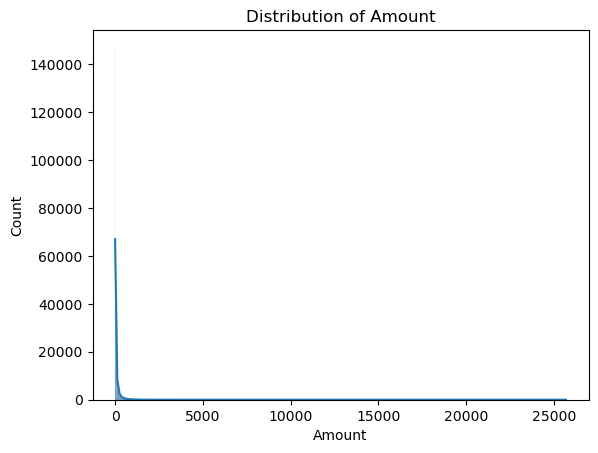

In [6]:
sns.histplot(df['Amount'], kde=True)
plt.title("Distribution of Amount")
plt.show()

In [7]:

# Use clean copy ONLY for statistics
df_numeric= df.apply(pd.to_numeric, errors='coerce')

# Generate around 200 rows (not fixed)
n_new = np.random.randint(180, 220)
print("new rows:",n_new)

new_data = pd.DataFrame()

for col in df.columns:
    
    if col == "Class":
        new_data[col] = np.random.choice([0, 1],size=n_new, p=[0.95, 0.05]) #target column only 0 and 1
    
    else: #genaerate numeric data based on original dataset
        if df_numeric[col].std()==0 or np.isnan(df_numeric[col].std()):
            new_data[col]=np.full(n_new,df_numeric[col].mean())
        else:
            new_data[col] = np.random.normal(
            loc=df_numeric[col].mean(),
            scale=df_numeric[col].std(),
            size=n_new
        )
        
       

# Add mixed data (string + numeric)
for col in new_data.columns:
    if col != "Class":
        new_data[col] = new_data[col].astype(object)
        mask = np.random.rand(n_new) < 0.1
        new_data.loc[mask, col] = new_data.loc[mask, col].astype(str)

# Add missing values
#new_data = new_data.mask(np.random.rand(*new_data.shape) < 0.1)
mask=np.random.rand(*new_data.shape) < 0.1
for i,col in enumerate(new_data.columns):
    if col!="Class":
        new_data.loc[mask[:,i],col]=np.nan

# Combine with original dataset
df = pd.concat([df, new_data], ignore_index=True)

print(" Dirty dataset created")
#print("new data:",new_data)
print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())

new rows: 210
 Dirty dataset created
Shape: (285017, 31)
Missing values:
 Time      23
V1        24
V2        14
V3        22
V4        19
V5        17
V6        10
V7        22
V8        27
V9        26
V10       25
V11       30
V12       17
V13       22
V14       23
V15       21
V16       25
V17       20
V18       11
V19       17
V20       24
V21       19
V22       23
V23       21
V24       21
V25       17
V26       22
V27       21
V28       13
Amount    13
Class      0
dtype: int64


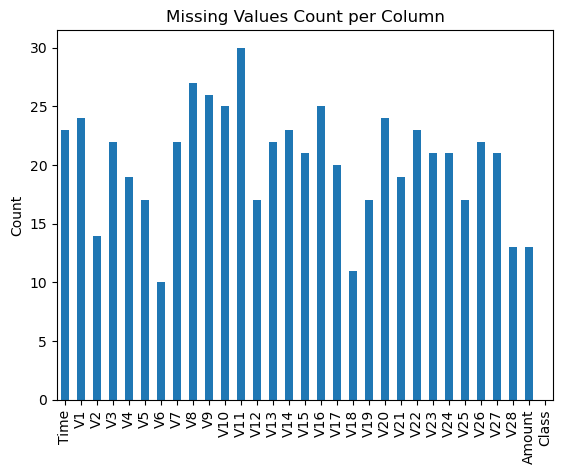

In [8]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()

missing.plot(kind='bar')
plt.title("Missing Values Count per Column")
plt.ylabel("Count")
plt.show()

In [9]:
# convert to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# handle missing values
for col in df.columns:
    if col=="Class":
        #drop row if class is missing
        df=df.dropna(subset=[col])
    else:
        #fill with mean
        df[col]=df[col].fillna(df[col].mean())
#df.fillna(df.mean(), inplace=True)

print("Data cleaned ")
print("Missing values after cleaning:\n", df.isnull().sum())
df["Class"]=df['Class'].astype(int)
print(df.dtypes)

Data cleaned 
Missing values after cleaning:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: obje

In [10]:

# STEP 1: Check duplicates

dup_count = df.duplicated().sum()
print("Duplicate rows before handling:", dup_count)


# STEP 2: Add noise to duplicates

import numpy as np

dup_mask = df.duplicated()

for col in df.columns:
    if col != "Class":   # do NOT change target
        if np.issubdtype(df[col].dtype, np.number):
            
            noise = np.random.normal(0, 0.01, dup_mask.sum())
            df.loc[dup_mask, col] += noise


# STEP 3: Verify

print("Duplicate rows after handling:", df.duplicated().sum())

Duplicate rows before handling: 1081
Duplicate rows after handling: 0


In [11]:
features = [f"V{i}" for i in range(1, 29)]

outlier_summary = {}

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = outliers

# Show results
for col, count in outlier_summary.items():
    print(f"{col}: {count} outliers")

V1: 7070 outliers
V2: 13541 outliers
V3: 3365 outliers
V4: 11147 outliers
V5: 12295 outliers
V6: 22964 outliers
V7: 8959 outliers
V8: 24190 outliers
V9: 8290 outliers
V10: 9507 outliers
V11: 780 outliers
V12: 15354 outliers
V13: 3372 outliers
V14: 14150 outliers
V15: 2897 outliers
V16: 8192 outliers
V17: 7426 outliers
V18: 7535 outliers
V19: 10213 outliers
V20: 27805 outliers
V21: 14540 outliers
V22: 1318 outliers
V23: 18589 outliers
V24: 4776 outliers
V25: 5364 outliers
V26: 5599 outliers
V27: 39206 outliers
V28: 30390 outliers


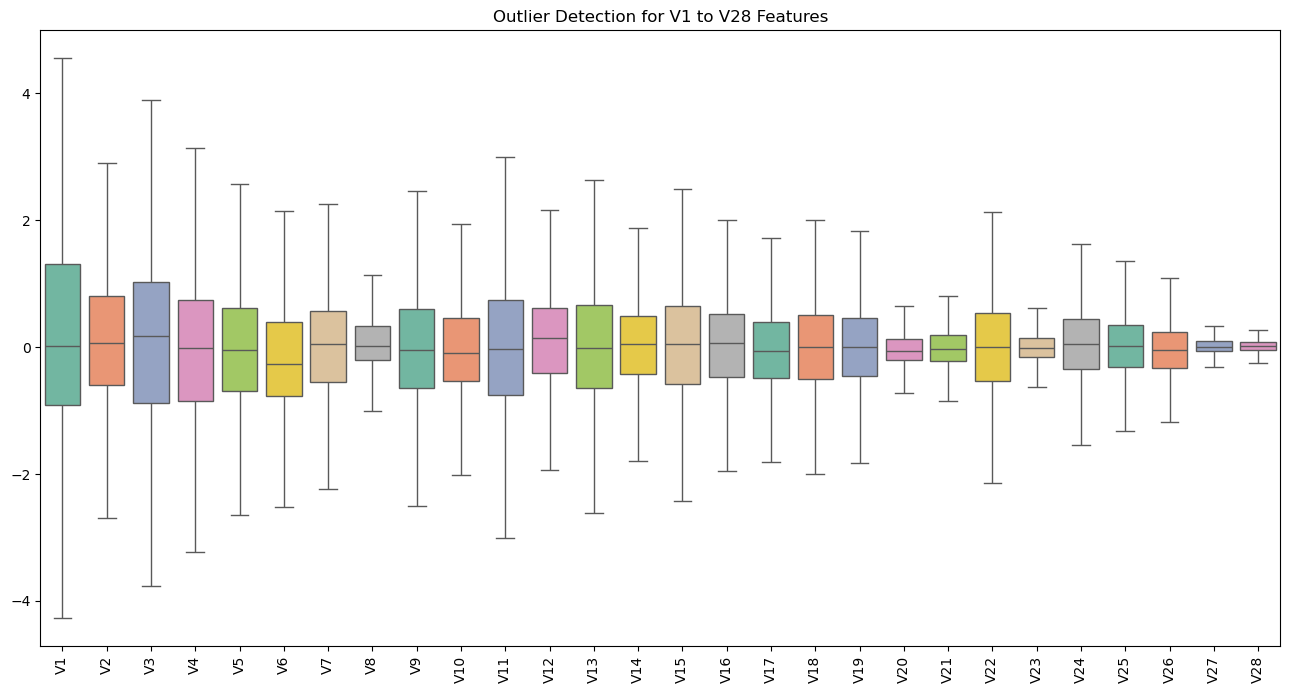

In [12]:
v_cols=[f'V{i}' for i in range(1,29)]

plt.figure(figsize=(16,8))
sns.boxplot(data=df[v_cols], palette="Set2", showfliers=False)
plt.xticks(rotation=90)
plt.title("Outlier Detection for V1 to V28 Features")
plt.show()

In [13]:
print("\nApplying outlier handling...\n")

bounds = {}

# Step 1: Calculate bounds and apply clipping
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    bounds[col] = (lower, upper)
    df[col] = df[col].clip(lower, upper)

# Step 2: Re-check using same bounds
print("Outliers handled in V1–V28")
print("After Handling\n")

for col in features:
    lower, upper = bounds[col]
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers} outliers")




Applying outlier handling...

Outliers handled in V1–V28
After Handling

V1: 0 outliers
V2: 0 outliers
V3: 0 outliers
V4: 0 outliers
V5: 0 outliers
V6: 0 outliers
V7: 0 outliers
V8: 0 outliers
V9: 0 outliers
V10: 0 outliers
V11: 0 outliers
V12: 0 outliers
V13: 0 outliers
V14: 0 outliers
V15: 0 outliers
V16: 0 outliers
V17: 0 outliers
V18: 0 outliers
V19: 0 outliers
V20: 0 outliers
V21: 0 outliers
V22: 0 outliers
V23: 0 outliers
V24: 0 outliers
V25: 0 outliers
V26: 0 outliers
V27: 0 outliers
V28: 0 outliers


In [14]:
print(df['Class'].value_counts())

Class
0    284506
1       511
Name: count, dtype: int64


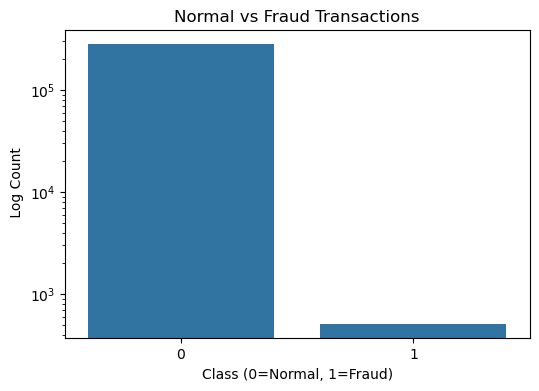

In [15]:
#log scale graph
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.yscale('log')
plt.title("Class Distributions (Log Scale)")
plt.title("Normal vs Fraud Transactions")
plt.xlabel("Class (0=Normal, 1=Fraud)")
plt.ylabel(" Log Count")
plt.show()

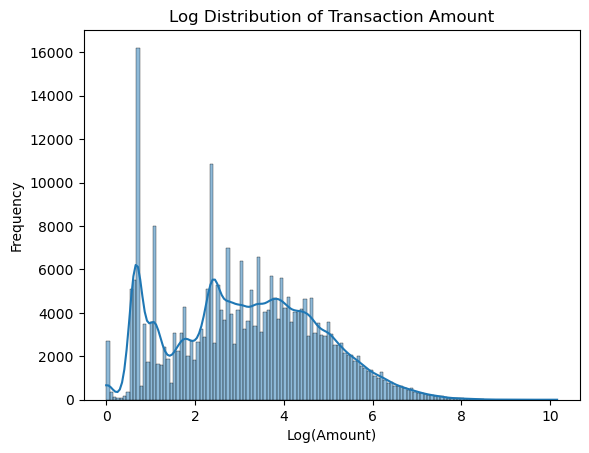

In [16]:
# Remove negative or invalid values
df_clean = df[df['Amount'] >= 0]

sns.histplot(np.log1p(df_clean['Amount']), kde=True)

plt.title("Log Distribution of Transaction Amount")
plt.xlabel("Log(Amount)")
plt.ylabel("Frequency")
plt.show()

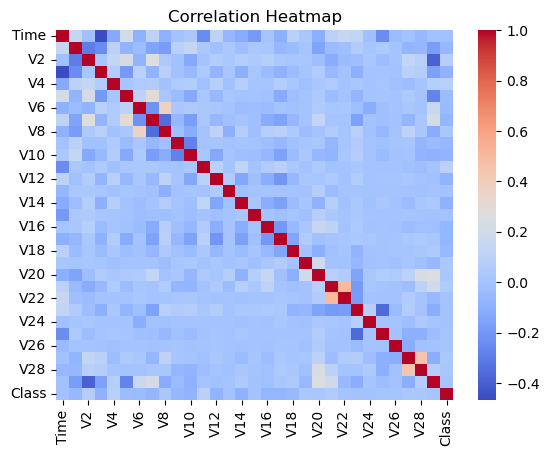

In [17]:
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [18]:
import plotly.graph_objects as go
fraud = df[df['Class'] == 1]


fig = go.Figure(go.Scatter(
    x=fraud['Time'], 
    y=fraud['Amount'],
    mode="markers",
    name="Amount",
    text=fraud['Amount'],
    marker=dict(color='rgb(238,23,11)', opacity=0.5, line=dict(color='red', width=1))
))

fig.update_layout(
    title='Amount of fraudulent transactions',
    xaxis_title='Time [s]',
    yaxis_title='Amount',
    hovermode='closest'
)


fig.show(renderer="iframe")

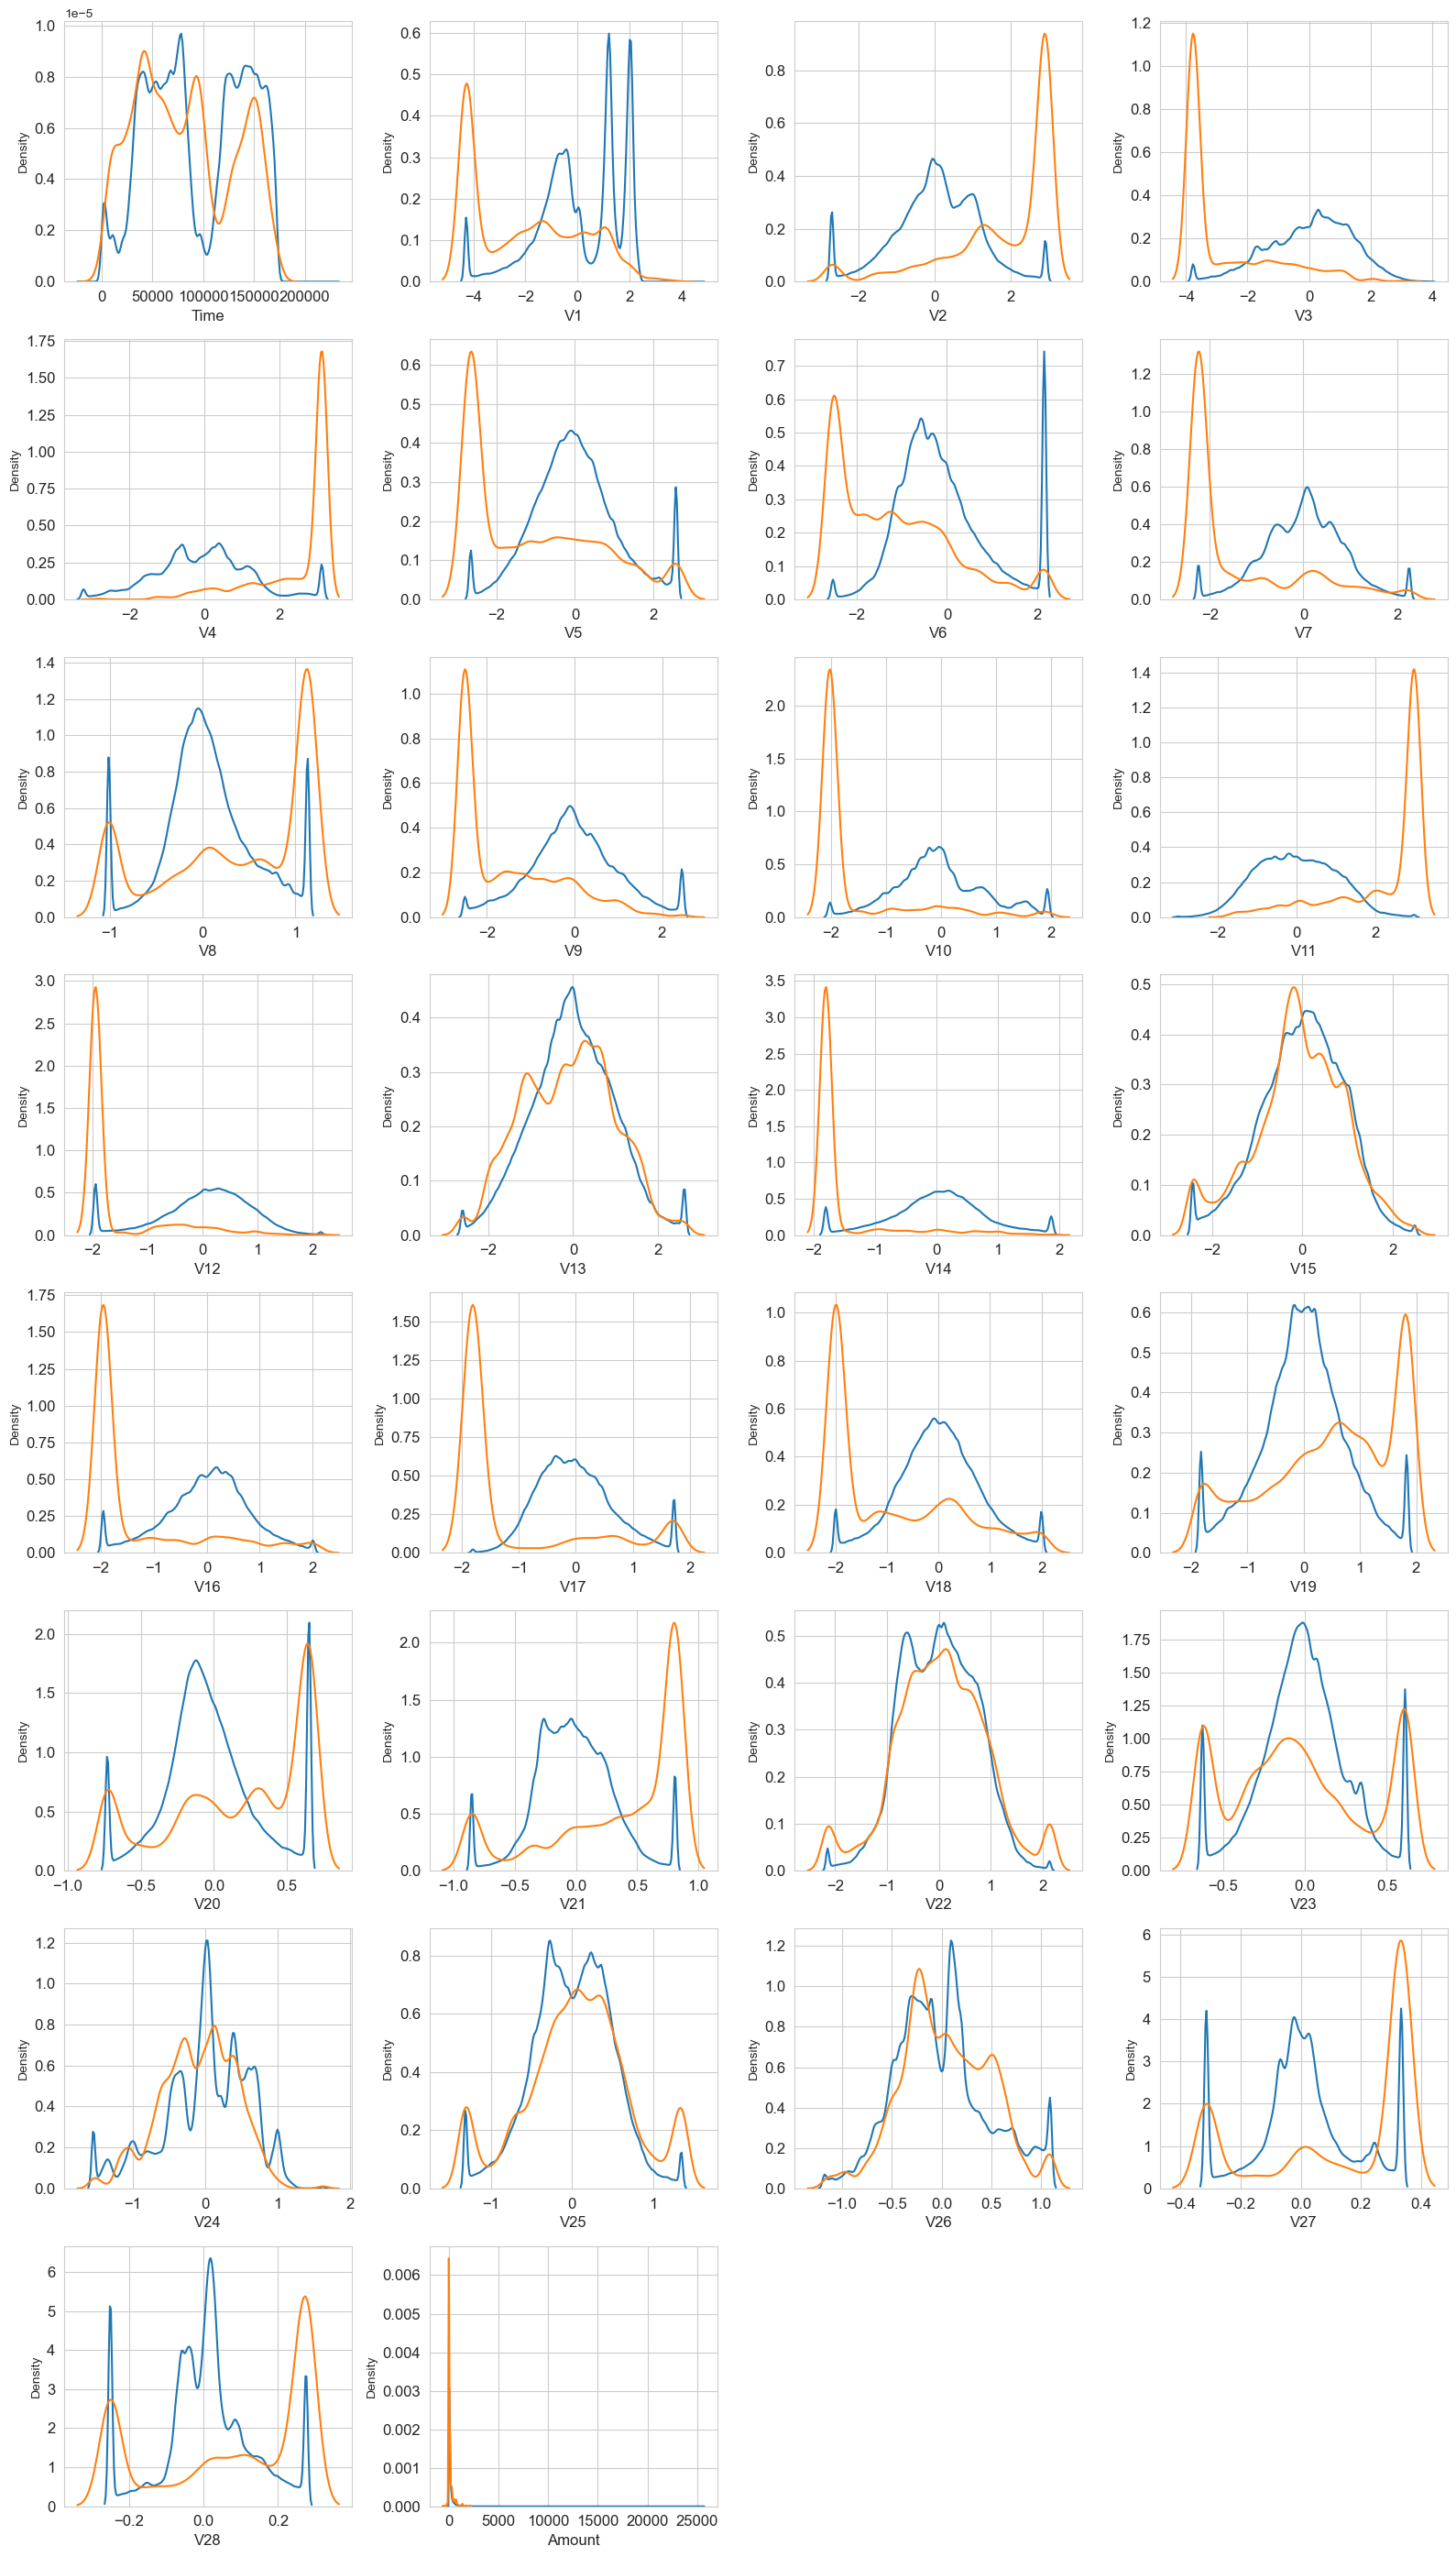

In [19]:
t0 = df[df['Class'] == 0]
t1 = df[df['Class'] == 1]

features = df.columns.drop('Class')

sns.set_style('whitegrid')
fig, axes = plt.subplots(8, 4, figsize=(16, 28))
axes = axes.flatten() 

for i, feature in enumerate(features):
    sns.kdeplot(data=t0, x=feature, bw_adjust=0.5, label="Class = 0", ax=axes[i], warn_singular=False)
    sns.kdeplot(data=t1, x=feature, bw_adjust=0.5, label="Class = 1", ax=axes[i], warn_singular=False)
    
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].tick_params(axis='both', which='major', labelsize=12)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() 
plt.show()
# Blue:Normal Transaction
# Orangr:Fraud Transaction

In [20]:
x = df.drop("Class", axis=1)
y = df["Class"]

In [21]:
x

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.000000,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.620000
1,0.000000,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000
2,1.000000,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.612139,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.660000
3,1.000000,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500000
4,2.000000,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.990000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285012,11753.710408,1.876520,-2.702797,-0.450465,-0.590726,-0.302025,0.168425,-2.240943,-0.000004,-1.801250,...,0.000036,0.782030,0.000009,0.512097,-0.177503,0.000025,0.344936,0.334052,-0.249962,-123.508511
285013,125110.421490,1.363112,1.830904,-1.228211,-0.926488,0.000033,-0.297398,-0.000075,1.131681,-0.014606,...,0.650542,0.808812,0.741884,-0.151840,0.108620,0.000025,0.176782,0.334052,0.275299,-517.150195
285014,78348.665654,2.894275,-2.702797,0.000086,1.557578,1.738994,-1.394133,-0.000075,1.131681,-1.358521,...,-0.729147,0.457692,0.344652,-0.237173,0.074785,0.436184,-1.146994,0.046432,-0.249962,240.434019
285015,50463.414843,0.396114,-0.274722,0.000086,-1.198529,0.000033,-0.171335,0.361238,0.516929,0.797847,...,0.650542,0.078348,0.000009,0.406715,0.440477,-0.219247,-0.063549,-0.313846,0.275299,583.026723


In [22]:
y

0         0
1         0
2         0
3         0
4         0
         ..
285012    0
285013    1
285014    0
285015    0
285016    0
Name: Class, Length: 285017, dtype: int64

In [23]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42,stratify=y
)

In [24]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [25]:
lr = LogisticRegression(max_iter=5000,class_weight="balanced")
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [26]:
knn=KNeighborsClassifier(weights="distance")
knn.fit(x_train,y_train)

,n_neighbors,5
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [27]:
dt=DecisionTreeClassifier(class_weight="balanced")
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [28]:
rf = RandomForestClassifier(class_weight="balanced")
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 556.4889975550122


In [30]:
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight)
xgb.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [31]:
stack = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb',xgb)
    ],
    final_estimator=LogisticRegression()
)

stack.fit(x_train, y_train)

,estimators,"[('rf', ...), ('xgb', ...)]"
,final_estimator,LogisticRegression()
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [32]:
y_pred_lr = lr.predict(x_test)
print("logistic regression prediction::",y_pred_lr)
y_prob_lr=lr.predict_proba(x_test)[:,1]
print("probability:",y_prob_lr)
lr_accuracy=accuracy_score(y_test, y_pred_lr)
print("lr accuracy:",lr_accuracy)
print("lr confusion matrix:\n",confusion_matrix(y_test, y_pred_lr))
precisionlr=precision_score(y_test,y_pred_lr)
print("lr precision score::",precisionlr)
f1_scorelr=f1_score(y_test,y_pred_lr)
print("lr f1 score::",f1_scorelr)
recalllr=recall_score(y_test,y_pred_lr)
print("lr recall score::",recalllr)

logistic regression prediction:: [0 0 0 ... 0 0 0]
probability: [0.12199591 0.03399357 0.02246506 ... 0.03019707 0.05609951 0.04249949]
lr accuracy: 0.9654936495684513
lr confusion matrix:
 [[54951  1951]
 [   16    86]]
lr precision score:: 0.04221894943544428
lr f1 score:: 0.08041140719962599
lr recall score:: 0.8431372549019608


In [33]:
y_pred_knn = knn.predict(x_test)
print("prediction::",y_pred_knn)
y_prob_knn=knn.predict_proba(x_test)[:,1]
print("probability:",y_prob_knn)
knn_accuracy=accuracy_score(y_test, y_pred_knn)
print("KNN accuracy:",knn_accuracy)
print("KNN confusion matrix:\n",confusion_matrix(y_test, y_pred_knn))
precisionknn=precision_score(y_test,y_pred_knn)
print("knn precision score::",precisionknn)
recallknn=recall_score(y_test,y_pred_knn)
print("knn recall score::",recallknn)
f1_scoreknn=f1_score(y_test,y_pred_knn)
print("knn f1 score::",f1_scoreknn)


prediction:: [0 0 0 ... 0 0 0]
probability: [0. 0. 0. ... 0. 0. 0.]
KNN accuracy: 0.9993158374850888
KNN confusion matrix:
 [[56893     9]
 [   30    72]]
knn precision score:: 0.8888888888888888
knn recall score:: 0.7058823529411765
knn f1 score:: 0.7868852459016393


In [34]:
y_pred_dt = dt.predict(x_test)
print("dt prediction::",y_pred_dt)
y_prob_dt=dt.predict_proba(x_test)[:,1]
print("dt probability:",y_prob_dt)
dt_accuracy=accuracy_score(y_test, y_pred_dt)
print("DT accuracy:",dt_accuracy)
print("DT confusion matrix:\n",confusion_matrix(y_test, y_pred_dt))
precisiondt=precision_score(y_test,y_pred_dt)
print("dt precision score::",precisiondt)
recalldt=recall_score(y_test,y_pred_dt)
print("dt recall score::",recalldt)
f1_scoredt=f1_score(y_test,y_pred_dt)
print("dt f1 score::",f1_scoredt)


dt prediction:: [0 0 0 ... 0 0 0]
dt probability: [0. 0. 0. ... 0. 0. 0.]
DT accuracy: 0.9989825275419268
DT confusion matrix:
 [[56872    30]
 [   28    74]]
dt precision score:: 0.7115384615384616
dt recall score:: 0.7254901960784313
dt f1 score:: 0.7184466019417476


In [35]:
y_pred_rf = rf.predict(x_test)
print("rf prediction ::",y_pred_rf)
y_prob_rf=rf.predict_proba(x_test)[:,1]
print("rf prob:",y_prob_rf)
accuracyrf=accuracy_score(y_test, y_pred_rf)
print("accuracy:",accuracyrf)
print("confusion matrix:\n",confusion_matrix(y_test, y_pred_rf))
f1_scorerf=f1_score(y_test,y_pred_rf)
print("f1_score:",f1_scorerf)
precisionrf=precision_score(y_test,y_pred_rf)
print("rf precision score::",precisionrf)
recallrf=recall_score(y_test,y_pred_rf)
print("rf recall score::",recallrf)

rf prediction :: [0 0 0 ... 0 0 0]
rf prob: [0. 0. 0. ... 0. 0. 0.]
accuracy: 0.9994035506280261
confusion matrix:
 [[56897     5]
 [   29    73]]
f1_score: 0.8111111111111111
rf precision score:: 0.9358974358974359
rf recall score:: 0.7156862745098039


In [36]:
y_pred_xgb = xgb.predict(x_test)
print("xgb prediction ::",y_pred_xgb)
y_prob_xgb=xgb.predict_proba(x_test)[:,1]
print("xgb prob:",y_prob_xgb)
accuracyxgb=accuracy_score(y_test, y_pred_xgb)
print("accuracy:",accuracyxgb)
print("confusion matrix:\n",confusion_matrix(y_test, y_pred_xgb))
f1_scorexgb=f1_score(y_test,y_pred_xgb)
print("f1_score:",f1_scorexgb)
precisionxgb=precision_score(y_test,y_pred_xgb)
print("xgb precision score::",precisionxgb)
recallxgb=recall_score(y_test,y_pred_xgb)
print("xgb recall score::",recallxgb)

xgb prediction :: [0 0 0 ... 0 0 0]
xgb prob: [7.4785945e-05 9.5546993e-06 1.6924998e-05 ... 1.4821542e-07 7.4250756e-06
 7.1356317e-07]
accuracy: 0.9993509227422637
confusion matrix:
 [[56891    11]
 [   26    76]]
f1_score: 0.8042328042328042
xgb precision score:: 0.8735632183908046
xgb recall score:: 0.7450980392156863


In [37]:
stack_pred = stack.predict(x_test)
y_prob_stack=stack.predict_proba(x_test)[:,1]

print("----- Stacking Result -----")

print("stack prob:",y_prob_stack)
accuracy_stack=accuracy_score(y_test, stack_pred)
print("combination of rf and xgboots using stack accuracy::",accuracy_stack)
f1_score_stack=f1_score(y_test,stack_pred)
print("combination of rf and xgboots using stack f1 score::",f1_score_stack)
precision_stack=precision_score(y_test,stack_pred)
print("combination of rf and xgboots using stack precision::",precision_stack)
recall_stack=recall_score(y_test,stack_pred)
print("combination of rf and xgboots using stack recall score ::",recall_stack)
print("classification of stack:\n",classification_report(y_test, stack_pred))
print("confusion matrix:\n",confusion_matrix(y_test, stack_pred))

----- Stacking Result -----
stack prob: [0.00044729 0.0004471  0.00044712 ... 0.00044707 0.00044709 0.00044707]
combination of rf and xgboots using stack accuracy:: 0.9993860079994387
combination of rf and xgboots using stack f1 score:: 0.8087431693989071
combination of rf and xgboots using stack precision:: 0.9135802469135802
combination of rf and xgboots using stack recall score :: 0.7254901960784313
classification of stack:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56902
           1       0.91      0.73      0.81       102

    accuracy                           1.00     57004
   macro avg       0.96      0.86      0.90     57004
weighted avg       1.00      1.00      1.00     57004

confusion matrix:
 [[56895     7]
 [   28    74]]


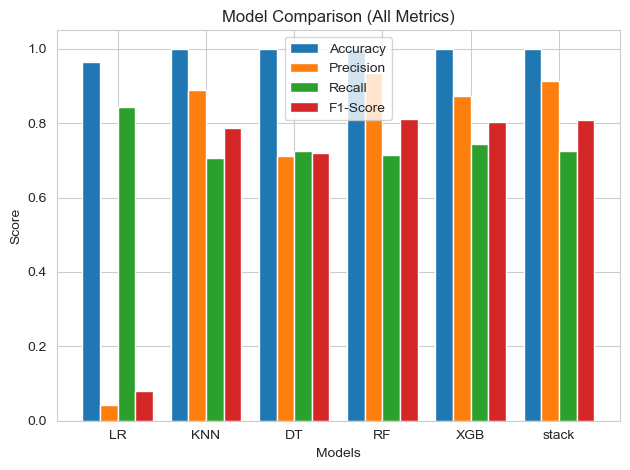

In [38]:
import matplotlib.pyplot as plt
import numpy as np

#  Model names
models = ["LR", "KNN", "DT", "RF", "XGB","stack"]

# Replace with your actual values
accuracy  = [lr_accuracy,knn_accuracy,dt_accuracy,accuracyrf,accuracyxgb,accuracy_stack]
precision = [precisionlr,precisionknn,precisiondt,precisionrf,precisionxgb,precision_stack]
recall    = [recalllr,recallknn, recalldt,recallrf,recallxgb,recall_stack]
f1score  = [f1_scorelr,f1_scoreknn,f1_scoredt,f1_scorerf,f1_scorexgb,f1_score_stack]

#  X-axis positions
x = np.arange(len(models))
width = 0.2

#  Create graph
plt.figure()

plt.bar(x - 1.5*width, accuracy,  width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall,    width, label='Recall')
plt.bar(x + 1.5*width, f1score,  width, label='F1-Score')

#  Labels and title
plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Comparison (All Metrics)")

#  X-axis labels
plt.xticks(x, models)

# Legend
plt.legend()

#  Layout
plt.tight_layout()

#  Show
plt.show()

In [39]:
param_grid={
    "C":[0.01,0.1,1,10,100],
    "penalty":["l2","l1"],
    "solver":["saga","liblinear"]
}
grid_lr=GridSearchCV(
    lr,
    param_grid,
    scoring="f1",
    cv=5,
    verbose=2,
    n_jobs=-1
)
grid_lr.fit(x_train,y_train)
print("best_parameter::",grid_lr.best_params_)
print("cv score::",grid_lr.best_score_)

best_model=grid_lr.best_estimator_
y_pred_gridlr=best_model.predict(x_test)
lr_grid_acc=accuracy_score(y_test,y_pred_gridlr)
print("Grid accuracy::",lr_grid_acc)
f1_scorelrgrid=grid_lr.score(x_test,y_test)
print("grid lr f1 score:",f1_scorelrgrid)
print("Grid confusin_matrix:\n",confusion_matrix(y_test,y_pred_gridlr))
print("Grid classification_report:\n",classification_report(y_test,y_pred_gridlr))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
best_parameter:: {'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}
cv score:: 0.09152264441788399
Grid accuracy:: 0.9667040909409866
grid lr f1 score: 0.08309178743961353
Grid confusin_matrix:
 [[55020  1882]
 [   16    86]]
Grid classification_report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98     56902
           1       0.04      0.84      0.08       102

    accuracy                           0.97     57004
   macro avg       0.52      0.91      0.53     57004
weighted avg       1.00      0.97      0.98     57004



In [41]:
from scipy.stats import uniform
param_dist = {
    "C": uniform(0.01, 100),   
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

random = RandomizedSearchCV(
    lr,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random.fit(x_train, y_train)

print("Best Parameters:", random.best_params_)
print("Best CV Score:", random.best_score_)

best_model_lr = random.best_estimator_

ypred_random_lr = best_model_lr.predict(x_test)
accuracy_lrrandom= accuracy_score(y_test, ypred_random_lr)
print("LR Random Accuracy:",accuracy_lrrandom)
f1_scorelrrandom=f1_score(y_test,ypred_random_lr)
print("lr random f1 score::",f1_scorelrrandom)
print("LR Random Score:", random.score(x_test, y_test))  # this is F1 internally

print("Confusion Matrix:\n", confusion_matrix(y_test, ypred_random_lr))
print("Classification Report:\n", classification_report(y_test, ypred_random_lr))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': np.float64(96.57320330745594), 'penalty': 'l2', 'solver': 'saga'}
Best CV Score: 0.08768647800620377
LR Random Accuracy: 0.9654761069398639
lr random f1 score:: 0.08037383177570094
LR Random Score: 0.08037383177570094
Confusion Matrix:
 [[54950  1952]
 [   16    86]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98     56902
           1       0.04      0.84      0.08       102

    accuracy                           0.97     57004
   macro avg       0.52      0.90      0.53     57004
weighted avg       1.00      0.97      0.98     57004



In [42]:
knn_grid={
    "n_neighbors":[3,5,7,9],
    "metric":["euclidean","manhattan"],
    "weights":["uniform","distance"]
}
grid_knn=GridSearchCV(
    knn,
    knn_grid,
    scoring="f1",
    n_jobs=-1,
    cv=5,
    verbose=2
)
grid_knn.fit(x_train,y_train)
print("best score::",grid_knn.best_score_)
print("cv score:",grid_knn.best_params_)

best_model_knn=grid_knn.best_estimator_
y_grid_knn=best_model_knn.predict(x_test)
print("KNN grid accuracy:",accuracy_score(y_test,y_grid_knn))
print("KNN grid confusion matrix:\n",confusion_matrix(y_test,y_grid_knn))
print("KNN grid classification_report\n",classification_report(y_test,y_grid_knn))
grid_knn_f1= grid_knn.score(x_test, y_test)
print("KNN grid f1 Score:",grid_knn_f1)  # this is F1 internally


Fitting 5 folds for each of 16 candidates, totalling 80 fits
best score:: 0.8380906834909488
cv score: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
KNN grid accuracy: 0.9992982948565013
KNN grid confusion matrix:
 [[56892    10]
 [   30    72]]
KNN grid classification_report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56902
           1       0.88      0.71      0.78       102

    accuracy                           1.00     57004
   macro avg       0.94      0.85      0.89     57004
weighted avg       1.00      1.00      1.00     57004

KNN grid f1 Score: 0.782608695652174


In [44]:
from scipy.stats import randint
knn_random={
    "n_neighbors":randint(3,10),
    "metric":["euclidean","manhattan"],
    "weights":["uniform","distance"]
}
random_knn=RandomizedSearchCV(
    knn,
    knn_random,
    scoring="f1",
    n_jobs=-1,
    verbose=2,
    cv=5,
    n_iter=20,
    random_state=42
)
random_knn.fit(x_train,y_train)
print("best score::",random_knn.best_score_)
print("cv score:",random_knn.best_params_)
print("knn randomized f1 score:",random_knn.score(x_test,y_test))

best_model_knn_random=random_knn.best_estimator_
y_random_knn=best_model_knn_random.predict(x_test)
knn_random_accuracy=accuracy_score(y_test,y_random_knn)
print("knn randomized accuracy:",knn_random_accuracy)
knn_randomf1=f1_score(y_test,y_random_knn)
print("knn random f1 score:",knn_randomf1)
print("knn randomized confusion matrix:\n",confusion_matrix(y_test,y_random_knn))
print("knn randomizedclassification_report\n",classification_report(y_test,y_random_knn))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
best score:: 0.8380906834909488
cv score: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
knn randomized f1 score: 0.782608695652174
knn randomized accuracy: 0.9992982948565013
knn random f1 score: 0.782608695652174
knn randomized confusion matrix:
 [[56892    10]
 [   30    72]]
knn randomizedclassification_report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56902
           1       0.88      0.71      0.78       102

    accuracy                           1.00     57004
   macro avg       0.94      0.85      0.89     57004
weighted avg       1.00      1.00      1.00     57004



In [45]:
dt_grid={
   "criterion":["gini","entropy"],
    "max_depth":[None,5,7],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,4]
}
grid_dt=GridSearchCV(
    dt,
    dt_grid,
    scoring="f1",
    n_jobs=-1,
    cv=5,
    verbose=2
)
grid_dt.fit(x_train,y_train)
print("best score::",grid_dt.best_score_)
print("cv score:",grid_dt.best_params_)

best_model_dt=grid_dt.best_estimator_
y_grid_dt=best_model_dt.predict(x_test)
f1_score_dtgrid=grid_dt.score(x_test,y_test)
print("f1score dt::",f1_score_dtgrid)
print("accuracy:",accuracy_score(y_test,y_grid_dt))
print("confusion matrix:\n",confusion_matrix(y_test,y_grid_dt))
print("classification_report\n",classification_report(y_test,y_grid_dt))


Fitting 5 folds for each of 24 candidates, totalling 120 fits
best score:: 0.719178145314449
cv score: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
f1score dt:: 0.7164179104477612
accuracy: 0.9990000701705144
confusion matrix:
 [[56875    27]
 [   30    72]]
classification_report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56902
           1       0.73      0.71      0.72       102

    accuracy                           1.00     57004
   macro avg       0.86      0.85      0.86     57004
weighted avg       1.00      1.00      1.00     57004



In [46]:
dt_random={
   "criterion":["gini","entropy"],
    "max_depth":[None,5,7],
    "min_samples_split":range(2,5),
    "min_samples_leaf":range(1,4)
}
random_dt=RandomizedSearchCV(
    dt,
    dt_random,
    scoring="f1",
    n_jobs=-1,
    cv=5,
    n_iter=20,
    random_state=42
)
random_dt.fit(x_train,y_train)
print("best score::",random_dt.best_score_)
print("cv score:",random_dt.best_params_)

best_model_dt=random_dt.best_estimator_
y_random_dt=best_model_dt.predict(x_test)
print("accuracy:",accuracy_score(y_test,y_random_dt))
print("confusion matrix:\n",confusion_matrix(y_test,y_random_dt))
print("classification_report\n",classification_report(y_test,y_random_dt))
f1_scorerandom_dt=random_dt.score(x_test,y_test)
print("f1 score::",f1_scorerandom_dt)


best score:: 0.7163002734502679
cv score: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'criterion': 'gini'}
accuracy: 0.9987720159988773
confusion matrix:
 [[56858    44]
 [   26    76]]
classification_report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56902
           1       0.63      0.75      0.68       102

    accuracy                           1.00     57004
   macro avg       0.82      0.87      0.84     57004
weighted avg       1.00      1.00      1.00     57004

f1 score:: 0.6846846846846847


In [47]:
rf_param_grid = {
    'n_estimators': [100, 155],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(x_train, y_train)

print("Best Parameters (RF Grid):", rf_grid.best_params_)
print("Best CV Score:", rf_grid.best_score_)
rf_grid_model = rf_grid.best_estimator_

y_pred_rf_grid = rf_grid_model.predict(x_test)
y_pred_f1score_random=rf_grid.score(x_test,y_test)
print("f1 score random forest grid search cv:",y_pred_f1score_random)
print("Accuracy:", accuracy_score(y_test, y_pred_rf_grid))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_grid))
print("Classification Report:\n", classification_report(y_test, y_pred_rf_grid))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters (RF Grid): {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 155}
Best CV Score: 0.826078525892363
f1 score random forest grid search cv: 0.8131868131868132
Accuracy: 0.9994035506280261
Confusion Matrix:
 [[56896     6]
 [   28    74]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56902
           1       0.93      0.73      0.81       102

    accuracy                           1.00     57004
   macro avg       0.96      0.86      0.91     57004
weighted avg       1.00      1.00      1.00     57004



In [48]:
rf_param_dist = {
    'n_estimators': randint(100, 300),        # 100 to 300
    'max_depth': randint(5, 20),              # 5 to 20
    'min_samples_split': randint(2, 10),      # 2 to 10
    'min_samples_leaf': randint(1, 5),        # 1 to 5
    'criterion': ['gini', 'entropy']
}

rf_random = RandomizedSearchCV(
    rf,
    rf_param_dist,
    n_iter=10,              # number of combinations
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rf_random.fit(x_train, y_train)

print("Best Parameters:", rf_random.best_params_)
print("Best CV Score:", rf_random.best_score_)
rf_random_model = rf_random.best_estimator_

y_pred = rf_random_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
y_pred_f1score_random=rf_random.score(x_test,y_test)
print("f1 score random forest grid search cv:",y_pred_f1score_random)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 18, 'min_samples_leaf': 3, 'min_samples_split': 7, 'n_estimators': 150}
Best CV Score: 0.8344298811247093
Accuracy: 0.9993684653708512
f1 score random forest grid search cv: 0.8064516129032258
Confusion Matrix:
 [[56893     9]
 [   27    75]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56902
           1       0.89      0.74      0.81       102

    accuracy                           1.00     57004
   macro avg       0.95      0.87      0.90     57004
weighted avg       1.00      1.00      1.00     57004



In [49]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

xgb_grid.fit(x_train, y_train)

print("Best Parameters (Grid):", xgb_grid.best_params_)
# F1 Score using .score()
grid_f1_score = xgb_grid.score(x_test, y_test)

print("Grid F1 Score:", grid_f1_score)

# Best Model
xgb_grid_model = xgb_grid.best_estimator_

y_pred_grid = xgb_grid_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_grid))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_grid))
print("Classification Report:\n", classification_report(y_test, y_pred_grid))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters (Grid): {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Grid F1 Score: 0.8042328042328042
Accuracy: 0.9993509227422637
Confusion Matrix:
 [[56891    11]
 [   26    76]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56902
           1       0.87      0.75      0.80       102

    accuracy                           1.00     57004
   macro avg       0.94      0.87      0.90     57004
weighted avg       1.00      1.00      1.00     57004



In [50]:
xgb_param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(3, 7),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.7, 0.3)
}

xgb_random = RandomizedSearchCV(
    xgb,
    param_distributions=xgb_param_dist,
    n_iter=10,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

xgb_random.fit(x_train, y_train)

print("Best Parameters (Random):", xgb_random.best_params_)
# F1 Score using .score()
random_f1_score = xgb_random.score(x_test, y_test)

print("Random F1 Score:", random_f1_score)

# Best Model
xgb_random_model = xgb_random.best_estimator_

y_pred_random = xgb_random_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_random))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_random))
print("Classification Report:\n", classification_report(y_test, y_pred_random))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters (Random): {'learning_rate': np.float64(0.16703519227860275), 'max_depth': 5, 'n_estimators': 207, 'subsample': np.float64(0.8542703315240834)}
Random F1 Score: 0.7958115183246073
Accuracy: 0.9993158374850888
Confusion Matrix:
 [[56889    13]
 [   26    76]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56902
           1       0.85      0.75      0.80       102

    accuracy                           1.00     57004
   macro avg       0.93      0.87      0.90     57004
weighted avg       1.00      1.00      1.00     57004



In [51]:
stack_grid = StackingClassifier(
    estimators=[('rf', rf_grid_model ), ('xgb', xgb_grid_model)],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

stack_grid.fit(x_train, y_train)

,estimators,"[('rf', ...), ('xgb', ...)]"
,final_estimator,LogisticRegression()
,cv,None
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,n_estimators,155
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [58]:
stack_pred_grid = stack_grid.predict(x_test)
y_prob_stack_grid=stack_grid.predict_proba(x_test)[:,1]

print("----- Stacking Result -----")

print("stack grid prob:",y_prob_stack_grid)
accuracy_stack_grid=accuracy_score(y_test, stack_pred_grid)
print("combination of rf and xgboots using stack grid accuracy::",accuracy_stack_grid)
f1_score_stack_grid=f1_score(y_test,stack_pred_grid)
print("combination of rf and xgboots using stack grid f1 score::",f1_score_stack_grid)
precision_stack_grid=precision_score(y_test,stack_pred_grid)
print("combination of rf and xgboots using stack grid precision::",precision_stack_grid)
recall_stack_grid=recall_score(y_test,stack_pred_grid)
print("combination of rf and xgboots using stack grid recall score ::",recall_stack_grid)
print("classification of grid stack:\n",classification_report(y_test, stack_pred_grid))
print("confusion matrix grid stack:\n",confusion_matrix(y_test, stack_pred_grid))

----- Stacking Result -----
stack grid prob: [0.00045599 0.00047053 0.00045601 ... 0.00045598 0.00045598 0.00045598]
combination of rf and xgboots using stack grid accuracy:: 0.9994210932566135
combination of rf and xgboots using stack grid f1 score:: 0.8176795580110497
combination of rf and xgboots using stack grid precision:: 0.9367088607594937
combination of rf and xgboots using stack grid recall score :: 0.7254901960784313
classification of grid stack:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56902
           1       0.94      0.73      0.82       102

    accuracy                           1.00     57004
   macro avg       0.97      0.86      0.91     57004
weighted avg       1.00      1.00      1.00     57004

confusion matrix grid stack:
 [[56897     5]
 [   28    74]]


In [55]:
stack_random = StackingClassifier(
    estimators=[('rf', rf_random_model), ('xgb', xgb_random_model)],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

stack_random.fit(x_train, y_train)

,estimators,"[('rf', ...), ('xgb', ...)]"
,final_estimator,LogisticRegression()
,cv,None
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,n_estimators,150
,criterion,'entropy'
,max_depth,18
,min_samples_split,7


In [56]:
stack_pred_random = stack_random.predict(x_test)
y_prob_stack_random=stack_random.predict_proba(x_test)[:,1]

print("----- Stacking Result -----")

print("stack random prob:",y_prob_stack_random)
accuracy_stack_random=accuracy_score(y_test, stack_pred_random)
print("combination of rf and xgboots using stack randomized accuracy::",accuracy_stack_random)
f1_score_stack_random=f1_score(y_test,stack_pred_random)
print("combination of rf and xgboots using stack randomized f1 score::",f1_score_stack_random)
precision_stack_random=precision_score(y_test,stack_pred_random)
print("combination of rf and xgboots using stack randomized precision::",precision_stack_random)
recall_stack_random=recall_score(y_test,stack_pred_random)
print("combination of rf and xgboots using stack randomized recall score ::",recall_stack_random)
print("classification of randomized  stack:\n",classification_report(y_test, stack_pred_random))
print("confusion matrix randomized stack:\n",confusion_matrix(y_test, stack_pred_random))

----- Stacking Result -----
stack random prob: [0.00038956 0.00038885 0.00038885 ... 0.00038883 0.00038883 0.00038883]
combination of rf and xgboots using stack randomized accuracy:: 0.9993860079994387
combination of rf and xgboots using stack randomized f1 score:: 0.8108108108108109
combination of rf and xgboots using stack randomized precision:: 0.9036144578313253
combination of rf and xgboots using stack randomized recall score :: 0.7352941176470589
classification of randomized  stack:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56902
           1       0.90      0.74      0.81       102

    accuracy                           1.00     57004
   macro avg       0.95      0.87      0.91     57004
weighted avg       1.00      1.00      1.00     57004

confusion matrix randomized stack:
 [[56894     8]
 [   27    75]]


In [59]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Simple", "Grid", "Random"],
    "Accuracy": [accuracy_stack, accuracy_stack_grid, accuracy_stack_random],
    "Precision": [precision_stack, precision_stack_grid, precision_stack_random],
    "Recall": [recall_stack, recall_stack_grid, recall_stack_random],
    "F1 Score": [f1_score_stack, f1_score_stack_grid, f1_score_stack_random]
})

print("\n===== MODEL COMPARISON TABLE =====")
print(comparison_df)


===== MODEL COMPARISON TABLE =====
    Model  Accuracy  Precision    Recall  F1 Score
0  Simple  0.999386   0.913580  0.725490  0.808743
1    Grid  0.999421   0.936709  0.725490  0.817680
2  Random  0.999386   0.903614  0.735294  0.810811


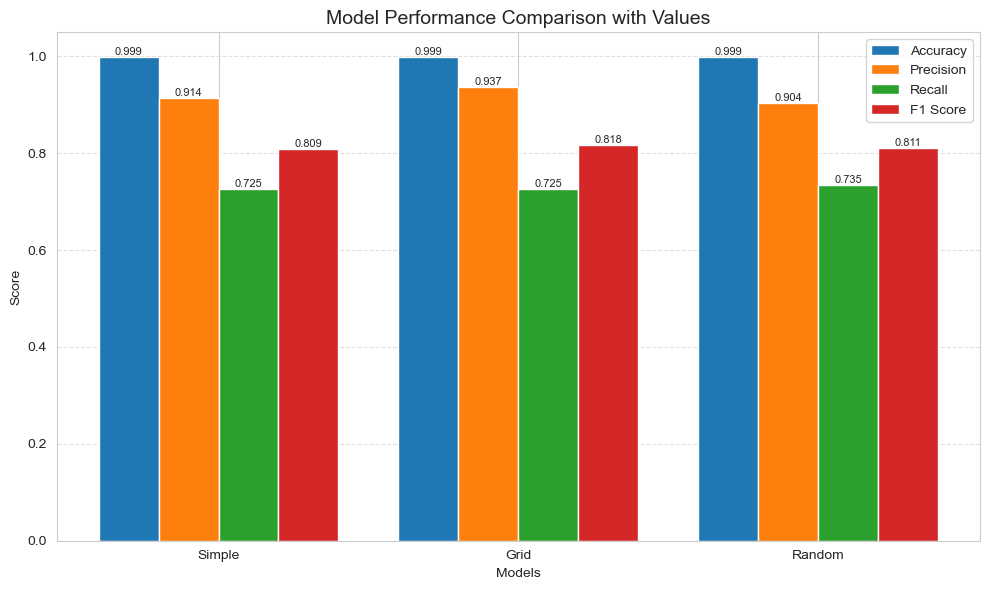

In [60]:
import numpy as np
import matplotlib.pyplot as plt

labels = ["Simple", "Grid", "Random"]

accuracy = [accuracy_stack, accuracy_stack_grid, accuracy_stack_random]
precision = [precision_stack, precision_stack_grid, precision_stack_random]
recall = [recall_stack, recall_stack_grid, recall_stack_random]
f1 = [f1_score_stack, f1_score_stack_grid, f1_score_stack_random]

x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
bars2 = plt.bar(x - 0.5*width, precision, width, label='Precision')
bars3 = plt.bar(x + 0.5*width, recall, width, label='Recall')
bars4 = plt.bar(x + 1.5*width, f1, width, label='F1 Score')

# 🔥 Add values on top
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f"{height:.3f}", ha='center', va='bottom', fontsize=8)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

plt.xticks(x, labels)
plt.title("Model Performance Comparison with Values", fontsize=14)
plt.xlabel("Models")
plt.ylabel("Score")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

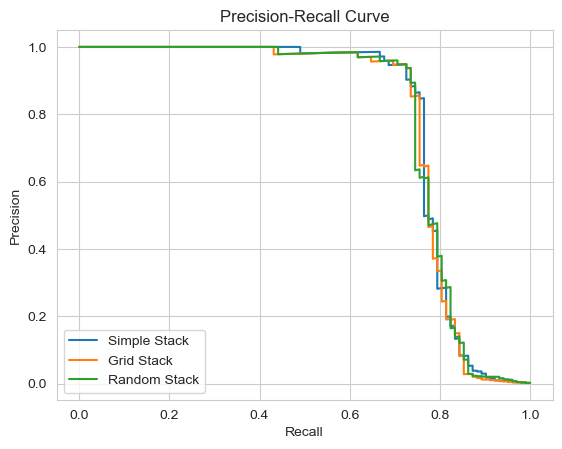

In [61]:
from sklearn.metrics import precision_recall_curve

plt.figure()

# Simple
p1, r1, _ = precision_recall_curve(y_test,y_prob_stack)
plt.plot(r1, p1, label="Simple Stack")

# Grid
p2, r2, _ = precision_recall_curve(y_test, y_prob_stack_grid)
plt.plot(r2, p2, label="Grid Stack")

# Random
p3, r3, _ = precision_recall_curve(y_test,  y_prob_stack_random)
plt.plot(r3, p3, label="Random Stack")

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

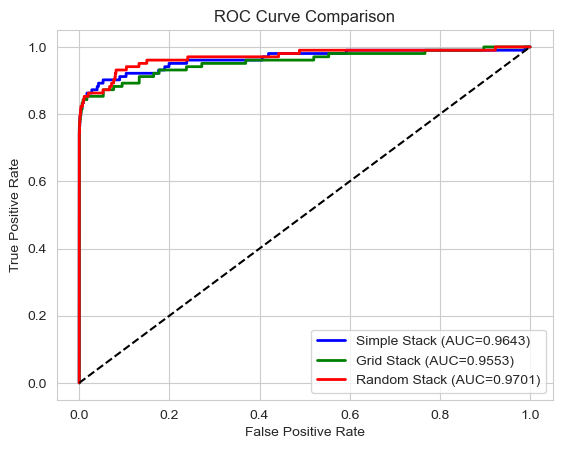

In [62]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

# Simple (Blue)
fpr1, tpr1, _ = roc_curve(y_test, y_prob_stack)
roc_auc1 = auc(fpr1, tpr1)
plt.plot(fpr1, tpr1, color='blue', linewidth=2,
         label=f"Simple Stack (AUC={roc_auc1:.4f})")

# Grid (Green)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_stack_grid)
roc_auc2 = auc(fpr2, tpr2)
plt.plot(fpr2, tpr2, color='green', linewidth=2,
         label=f"Grid Stack (AUC={roc_auc2:.4f})")

# Random (Red)
fpr3, tpr3, _ = roc_curve(y_test, y_prob_stack_random)
roc_auc3 = auc(fpr3, tpr3)
plt.plot(fpr3, tpr3, color='red', linewidth=2,
         label=f"Random Stack (AUC={roc_auc3:.4f})")

# Diagonal line
plt.plot([0,1],[0,1], linestyle='--', color='black')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.show()

In [63]:
models = {
    "Simple": (stack, f1_score_stack),
    "Grid": (stack_grid, f1_score_stack_grid),
    "Random": (stack_random, f1_score_stack_random)
}

best_model_name = max(models, key=lambda x: models[x][1])
best_model = models[best_model_name][0]

print("Best Model:", best_model_name)

Best Model: Grid


In [66]:
from sklearn.model_selection import StratifiedKFold,cross_val_score

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_simple = cross_val_score(stack, x_train, y_train, cv=cv, scoring='f1').mean()
cv_grid = cross_val_score(stack_grid, x_train, y_train, cv=cv, scoring='f1').mean()
cv_random = cross_val_score(stack_random, x_train, y_train, cv=cv, scoring='f1').mean()

# ===================== TEST METRICS =====================
def get_metrics(model):
    y_pred = model.predict(x_test)
    return (
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    )

acc_s, pre_s, rec_s, f1_s = get_metrics(stack)
acc_g, pre_g, rec_g, f1_g = get_metrics(stack_grid)
acc_r, pre_r, rec_r, f1_r = get_metrics(stack_random)
# ===================== COMPARISON =====================
models = {
    "Simple": {"model": stack, "acc": acc_s, "pre": pre_s, "rec": rec_s, "f1": f1_s, "cv": cv_simple},
    "Grid": {"model": stack_grid, "acc": acc_g, "pre": pre_g, "rec": rec_g, "f1": f1_g, "cv": cv_grid},
    "Random": {"model": stack_random, "acc": acc_r, "pre": pre_r, "rec": rec_r, "f1": f1_r, "cv": cv_random}
}
# ===================== WEIGHTED SCORE =====================
for name in models:
    m = models[name]
    m["score"] = (
        0.15 * m["acc"] +
        0.15 * m["pre"] +
        0.25 * m["rec"] +
        0.25 * m["f1"] +
        0.20 * m["cv"]
    )

# ===================== BEST MODEL =====================
best_model_name = max(models, key=lambda x: models[x]["score"])
best_model = models[best_model_name]["model"]

# ===================== OUTPUT =====================
print("\nMODEL COMPARISON:\n")
for name in models:
    m = models[name]
    print(f"{name}: Acc={m['acc']:.4f}, Pre={m['pre']:.4f}, Rec={m['rec']:.4f}, F1={m['f1']:.4f}, CV={m['cv']:.4f}, Score={m['score']:.4f}")

print("\nBEST MODEL:", best_model_name) 


MODEL COMPARISON:

Simple: Acc=0.9994, Pre=0.9136, Rec=0.7255, F1=0.8087, CV=0.8322, Score=0.8369
Grid: Acc=0.9994, Pre=0.9367, Rec=0.7255, F1=0.8177, CV=0.8315, Score=0.8425
Random: Acc=0.9994, Pre=0.9036, Rec=0.7353, F1=0.8108, CV=0.8320, Score=0.8384

BEST MODEL: Grid


In [68]:
import joblib

model_file=joblib.dump(best_model, "best_model.pkl")
scaler_file=joblib.dump(scaler, "scaler.pkl")
print(model_file)
print(scaler_file)

print("Model and Scaler Saved successfully!")

['best_model.pkl']
['scaler.pkl']
Model and Scaler Saved successfully!
